# Imports

In [26]:
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# DATA INLADEN 

In [27]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/closed-open-eyes/data")

parquet_files = sorted(DATA_DIR.rglob("*.parquet"))
df = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
df.columns = df.columns.str.replace("'", "")
print(df.shape)
print(df.head())

(126560, 6)
   Image_id      Left_eye_react     Right_eye_react        Label  \
0         0   [329, 219, 29, 9]  [230, 222, 49, 10]  closed_eyes   
1         1   [321, 202, 31, 9]  [221, 197, 46, 10]  closed_eyes   
2         2  [260, 187, 45, 10]   [166, 187, 39, 9]  closed_eyes   
3         3  [219, 235, 23, 15]  [141, 233, 41, 16]  closed_eyes   
4         4   [280, 223, 41, 8]   [204, 224, 30, 8]  closed_eyes   

                                     Image_data.file  \
0  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...   
1  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...   
2  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...   
3  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...   
4  b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...   

                                 Image_data.filename  
0  275d7560d5eafa88ce58e3f14d54c83f2fb53d783cdce7...  
1  e52c3338399bce2e03d4ac73b694a907b965f34cf16b72...  
2  752bda9bcada573aee18ce66051884ec6b22d6e11704ee...  
3  7f68a9f466ae287445e

# Label map + test image cell


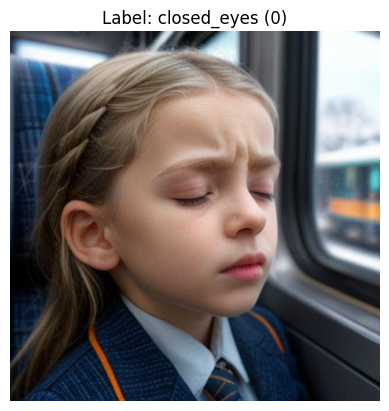

In [28]:
# 1. Definieer de mapping
label_map = {"closed_eyes": 0, "open_eyes": 1}

# 2. Voeg een kolom toe met de numerieke labels (optioneel, voor training)
df['Label_int'] = df['Label'].map(label_map)

# 3. Gebruik de mapped waarde in je visualisatie
sample = df.iloc[0]
img = Image.open(io.BytesIO(sample["Image_data.file"])).convert("RGB")

plt.imshow(img)
# Zet de tekst naar de waarde uit de map (0 of 1)
label_val = label_map.get(sample["Label"], "Unknown")
plt.title(f"Label: {sample['Label']} ({label_val})")
plt.axis("off")
plt.show()

# CACHING IMAGE RESIZE to make model training faster RUN ONLY ONCE 

In [29]:
from pathlib import Path
from PIL import Image
import io

CACHE_DIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/eye_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

rows = []

# Update the loop to use the correct column name
# 1. Strip the extra single quotes from all column names
df.columns = df.columns.str.replace("'", "")

# 2. Update your loop to use the correctly spelled column name
for i, row in df.iterrows():
    # Use the cleaned name: 'Image_data.file'
    img = Image.open(io.BytesIO(row["Image_data.file"])).convert("RGB")
    img = img.resize((224, 224))
    
    out_path = CACHE_DIR / f"{i}.jpg"
    img.save(out_path, quality=95)
    
    rows.append({"path": str(out_path), "Label": row["Label"]})

In [30]:
# Definieer de map
label_map = {"closed_eyes": 0, "open_eyes": 1}

# In je bestaande loop:
for i, row in df.iterrows():
    # ... (jouw bestaande code voor afbeelding opslaan) ...
    
    # Sla het getal op in plaats van de tekst
    label_numeric = label_map.get(row["Label"], 0) # Fallback naar 0
    rows.append({"path": str(out_path), "Label": label_numeric}) 

# Nu bevat je CSV ook 0 en 1
pd.DataFrame(rows).to_csv("dataset_met_getallen.csv", index=False)

# Simple dataset


In [31]:
class EyeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        label = torch.tensor(label_map[row["Label"]], dtype=torch.long)
        return img, label

# Split and loaders

In [32]:
print(cached_df.columns)
print(cached_df.head())

train_df, val_df = train_test_split(
    cached_df,
    test_size=0.2,
    random_state=42,
    stratify=cached_df["Label"]
)

train_ds = EyeDataset(train_df)
val_ds = EyeDataset(val_df)

Index(['path', 'Label'], dtype='object')
                                                path        Label
0  /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced...  closed_eyes
1  /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced...  closed_eyes
2  /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced...  closed_eyes
3  /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced...  closed_eyes
4  /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced...  closed_eyes


In [33]:
train_ds = EyeDataset(train_df)
val_ds = EyeDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# CNN CLASS

In [34]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.model(x)

# device training setup 

In [35]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using:", device)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Using: mps


# TRAIN 

In [36]:
for epoch in range(5):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    print(f"Epoch {epoch+1} | loss={running_loss:.4f} | acc={correct/total:.4f}")

Epoch 1 | loss=776.0668 | acc=0.8739
Epoch 2 | loss=141.1196 | acc=0.9840
Epoch 3 | loss=97.8229 | acc=0.9893
Epoch 4 | loss=77.4416 | acc=0.9915
Epoch 5 | loss=58.9632 | acc=0.9933


# VALIDATE

In [37]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

print(f"Validation accuracy: {correct/total:.4f}")

Validation accuracy: 0.9893


MODEL OPSLAAN

In [38]:
# Model opslaan (alleen state_dict voor flexibiliteit)
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,  # laatste epoch
    'loss': running_loss,
    'accuracy': correct/total
}, 'fatigue_model_complete.pth')

# Of alleen model weights (lichter)
torch.save(model.state_dict(), 'fatigue_model.pth')

print("Model opgeslagen! Gebruik in nieuwe notebook:")
print("model = YourModelClass()  # dezelfde architectuur")
print("model.load_state_dict(torch.load('fatigue_model.pth'))")
print("model.eval()")

Model opgeslagen! Gebruik in nieuwe notebook:
model = YourModelClass()  # dezelfde architectuur
model.load_state_dict(torch.load('fatigue_model.pth'))
model.eval()


TESTING ON NEW DATA